<h1 style="text-align: center; font-family: 'Roboto', sans-serif; font-weight:bold; font-size:40px; margin: 40px 0">02 - EDA : Feature Engineering Temporel</h1>

### Objectif
Les fichiers `in_time` et `out_time` contiennent des horodatages bruts au format wide
(une colonne par jour ouvré, une ligne par employé). Ces données ne peuvent pas être
injectées telles quelles dans un modèle. Il faut les transformer en features agrégées
(moyenne d'heures, fréquence d'heures supplémentaires, etc.).

### Plan de ce notebook
- Chargement des fichiers d'horaires
- Conversion en datetime
- Calcul du temps de travail quotidien
- Agrégation par employé
- Réflexion éthique

### Prérequis
- Avoir exécuté le notebook [01_eda_static_data.ipynb](./01_eda_static_data.ipynb) et compris la structure des données.

---
## **1. Importation des bibliothèques nécessaires**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_FILE_PATH = "../data/pre-processed/dynamic_merged.csv"

df_in  = pd.read_csv("../data/raw/in_time.csv", index_col=0, na_values=["NA"])
df_out = pd.read_csv("../data/raw/out_time.csv", index_col=0, na_values=["NA"])

sns.set_theme(style="whitegrid")

---
## **2. Chargement des fichiers d'horaires**

Dans cette première partie, il est question de rassembler les données dans un seul dataframe final aggrégé pour pouvoir ensuite les traiter correctement. Pour ce faire, nous suivrons le plan suivant :
- Comprendre le format utilisé
- Conversion en datetime
- Calcul du temps de travail quotidien
- Aggrégation par employé

### 2.1. Comprendre le format utilisé
Ces fichiers sont en format wide :
- Chaque ligne = un employé
- Chaque colonne = un jour ouvré (ex: `2015-01-02`, `2015-01-05`, ...)
- Chaque cellule = un horodatage (`2015-01-02 09:43:45`) ou `NA` si l'employé n'a pas travaillé ce jour-là

In [ ]:
print(f"in_time : {df_in.shape[0]} employés x {df_in.shape[1]} jours")
print(f"out_time : {df_out.shape[0]} employés x {df_out.shape[1]} jours")

# On vérifie que les deux fichiers ont la même structure
assert df_in.shape == df_out.shape, "Les deux fichiers n'ont pas la même dimension !"
assert (df_in.index == df_out.index).all(), "Les index employés ne correspondent pas !"
assert (df_in.columns == df_out.columns).all(), "Les colonnes dates ne correspondent pas !"

in_time : 4410 employés x 261 jours
out_time : 4410 employés x 261 jours


### 2.2. Conversion en datetime

Le Dataframe nous soumet des colonnes au type `object` ce qui n'est pas optimal pour des opérations temporelles. Nous décidons donc de le convertir en `datetime64`.

In [ ]:
# On transforme le type des données en datetime pour faciliter les analyses temporelles
df_in  = df_in.apply(pd.to_datetime, errors="coerce")
df_out = df_out.apply(pd.to_datetime, errors="coerce")

# Vérification rapide du type
print(f"Type d'une colonne in_time  : {df_in.iloc[:, 0].dtype}")
print(f"Type d'une colonne out_time : {df_out.iloc[:, 0].dtype}")

Type d'une colonne in_time  : datetime64[s]
Type d'une colonne out_time : datetime64[s]


### 2.3. Calcul du temps de travail quotidien

La soustraction de deux DataFrames `datetime64` produit un DataFrame de `timedelta64`.
On peut ensuite convertir en heures décimales en divisant par `pd.Timedelta(hours=1)`.

Il est à noter que cette opération est entièrement vectorisée, il n'y a donc pas de boucle nécessaire !

In [ ]:
# On effectue une soustraction vectorisée : chaque cellule devient la durée travaillée ce jour
df_hours = (df_out - df_in) / pd.Timedelta(hours=1)

print(f"Dimensions : {df_hours.shape}")
print(f"\nAperçu (employé 1, 5 premiers jours) :")
print(df_hours.iloc[0, :5])

Dimensions : (4410, 261)

Aperçu (employé 1, 5 premiers jours) :
2015-01-01         NaN
2015-01-02    7.208333
2015-01-05    7.189722
2015-01-06    7.410833
2015-01-07    7.006667
Name: 1, dtype: float64


### 2.4. Agrégation par employé

Notre modèle de classification s'attend à obtenir une ligne par employé avec des features numériques.
Les 261 colonnes de durées quotidiennes doivent être résumées en quelques indicateurs que voici :
- `avg_hours_per_day` : Moyenne d'heures travaillées par jour
- `std_hours_daily` : Écart-type d'heures travaillées par jour
- `std_hours_monthly` : Écart-type d'heures travaillés par mois 
- `total_days_worked` : Nombre de jours travaillés sur l'année
- `overtime_ratio` : Valeur entre 0 et 1 permettant de déterminer le taux de jours où l'employé a travaillé avec des heures supplémentaires.

In [ ]:
OVERTIME_THRESHOLD = 8

df_time_features = pd.DataFrame(index=df_hours.index)
df_time_features.index.name = "employee_id"

df_time_features["avg_hours_per_day"]  = df_hours.mean(axis=1)
df_time_features["std_hours_daily"]    = df_hours.std(axis=1)
months = pd.to_datetime(df_hours.columns).month
monthly_avg = df_hours.T.groupby(months).mean().T
df_time_features["std_hours_monthly"]  = monthly_avg.std(axis=1)
df_time_features["total_days_worked"]  = df_hours.notna().sum(axis=1)
df_time_features["overtime_ratio"]     = (
    (df_hours > OVERTIME_THRESHOLD).sum(axis=1) / df_hours.notna().sum(axis=1)
)

Export : (4410, 5)
       avg_hours_per_day  std_hours_daily  std_hours_monthly  \
count            4410.00          4410.00            4410.00   
mean                7.70             0.30               0.07   
std                 1.34             0.01               0.01   
min                 5.95             0.25               0.03   
25%                 6.67             0.29               0.06   
50%                 7.41             0.30               0.07   
75%                 8.37             0.31               0.08   
max                11.03             0.34               0.12   

       total_days_worked  overtime_ratio  
count            4410.00         4410.00  
mean              236.27            0.32  
std                 5.50            0.42  
min               225.00            0.00  
25%               232.00            0.00  
50%               236.00            0.03  
75%               241.00            0.88  
max               248.00            1.00  


### 2.5. Exportation en CSV

In [ ]:
df_time_features.to_csv(DATA_FILE_PATH)
print(f"Export : {df_time_features.shape}")
print(df_time_features.describe().round(2))

## **3. Analyse des features temporelles**

Enfin, il est intéressant de visualiser les données que nous venons d'aggréger sous forme d'histogramme par feature :

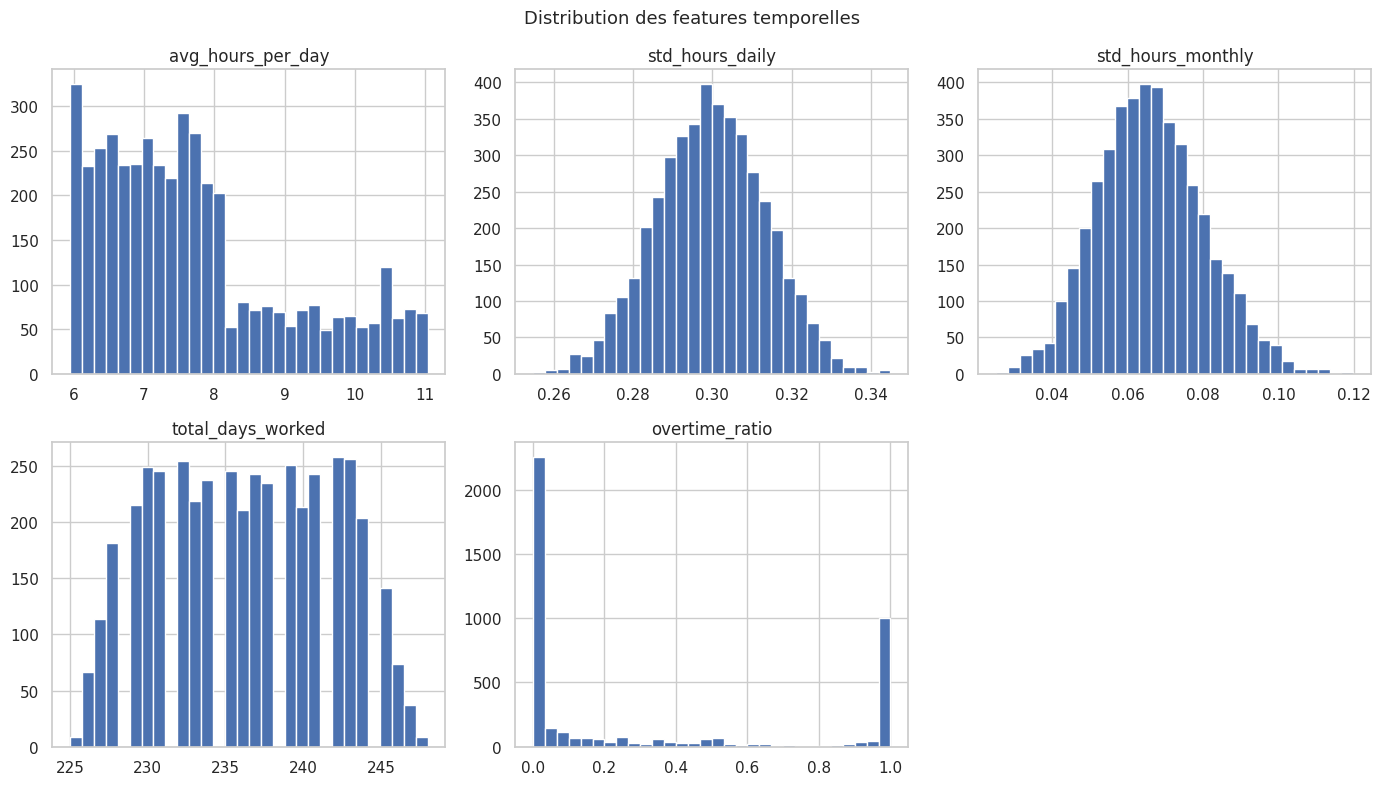

Heures négatives : 0
Jours travaillés > 365 : 0
Overtime ratio > 1 : 0


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, df_time_features.columns):
    ax.hist(df_time_features[col].dropna(), bins=30, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")

axes[-1].set_visible(False)
plt.suptitle("Distribution des features temporelles", fontsize=13)
plt.tight_layout()
plt.show()

# Valeurs aberrantes physiquement impossibles
print("Heures négatives :", (df_time_features["avg_hours_per_day"] < 0).sum())
print("Jours travaillés > 365 :", (df_time_features["total_days_worked"] > 365).sum())
print("Overtime ratio > 1 :", (df_time_features["overtime_ratio"] > 1).sum())

---
<div style="display: flex; justify-content: space-between;">
  <a href="./01_eda_static_data.ipynb">Précédent</a>
  <a href="./03_eda_merge_data.ipynb">Suivant</a>
</div>